### DataFrame

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

epochs = np.arange(1, 51)

df_prod = pd.DataFrame({
    "epoch": epochs,
    "train_loss": np.exp(-epochs / 10) + np.random.normal(0, 0.02, len(epochs)),
    "val_loss": np.exp(-epochs / 9) + np.random.normal(0, 0.03, len(epochs)),
    "train_accuracy": 1 - np.exp(-epochs / 10) + np.random.normal(0, 0.01, len(epochs)),
    "val_accuracy": 1 - np.exp(-epochs / 9) + np.random.normal(0, 0.015, len(epochs)),
    "learning_rate": np.where(epochs < 25, 0.01, 0.001),
})

df_prod.head()

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,learning_rate
0,1,0.914772,0.904562,0.081009,0.108918,0.01
1,2,0.815965,0.789185,0.177063,0.204459,0.01
2,3,0.753772,0.696224,0.255755,0.273268,0.01
3,4,0.700781,0.659531,0.321657,0.362303,0.01
4,5,0.601848,0.604683,0.391856,0.430643,0.01


### DataFrame Schema
| Column         | Type            | Meaning                    |
| -------------- | --------------- | -------------------------- |
| epoch          | Index / Feature | Training step              |
| train_loss     | Metric          | Optimization performance   |
| val_loss       | Metric          | Generalization performance |
| train_accuracy | Metric          | Train set accuracy         |
| val_accuracy   | Metric          | Validation accuracy        |
| learning_rate  | Config          | Hyperparameter schedule    |


#### Honest & Clear Plots

Text(0, 0.5, 'Validation Loss')

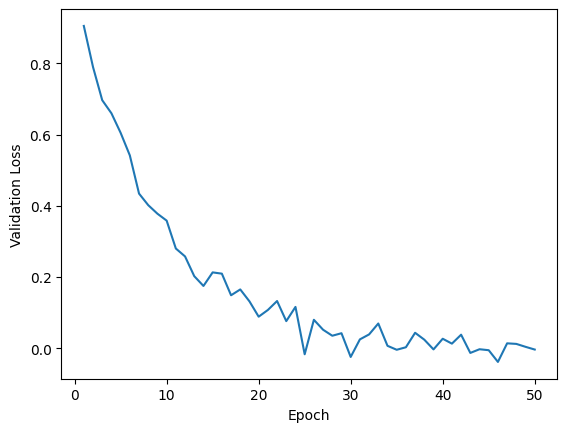

In [5]:
fig, ax = plt.subplots()

ax.plot(df_prod["epoch"], df_prod["val_loss"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")

#### Avoiding Misleading Axes

In [8]:
ax.set_ylim(0, 1.2)


(0.0, 1.2)

#### Reproducible & Consistent Styling

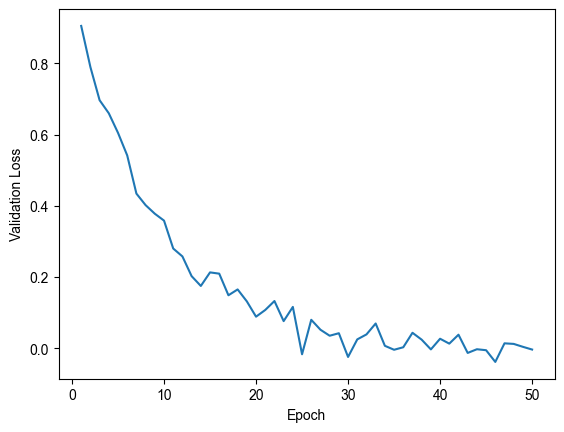

In [9]:
fig, ax = plt.subplots()

ax.plot(df_prod["epoch"], df_prod["val_loss"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")

sns.set_theme(style="whitegrid", palette="colorblind")

#### Exporting for Reports

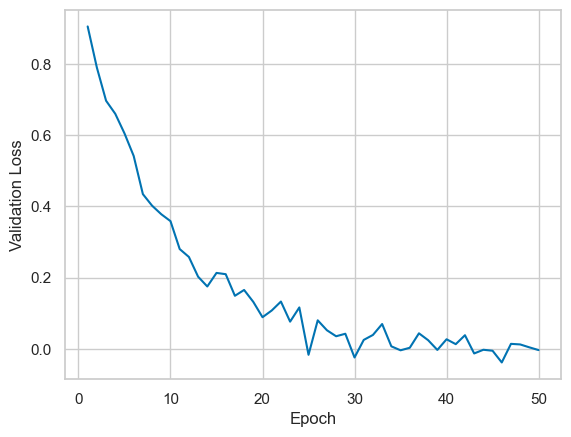

In [11]:
fig, ax = plt.subplots()

ax.plot(df_prod["epoch"], df_prod["val_loss"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")

plt.savefig("08_training_metrics.png", dpi=300, bbox_inches="tight")

#### Dashboard / Streamlit Usage
```python
st.line_chart(df_prod.set_index("epoch")[["train_loss", "val_loss"]])
```